# Bab 8 — Learning Signal and Ignoring Noise: Introduction to Regularization and Batching

Notebook ini merangkum **Bab 8** buku *Grokking Deep Learning* (Andrew W. Trask, 2019).

Kita menerapkan network 3 layer dari Bab 6 ke dataset nyata (**MNIST**) dan menemukan masalah besar: **overfitting**. Bab ini memperkenalkan cara mengatasinya — **early stopping** dan **dropout** — serta **mini-batch gradient descent** untuk training yang lebih cepat dan stabil.

Isi notebook:
1. Network 3 layer pada MNIST
2. Memorization vs generalization
3. Overfitting pada neural network & dari mana asalnya
4. Regularisasi paling sederhana: early stopping
5. Regularisasi standar industri: dropout
6. Mengapa dropout bekerja: ensembling
7. Dropout dalam kode & evaluasinya pada MNIST
8. Batch gradient descent

## 0. Setup

In [1]:
from pathlib import Path
import urllib.request

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
np.random.seed(1)

DATA_DIR = Path('data')
BOOK_URL = 'https://raw.githubusercontent.com/iamtrask/Grokking-Deep-Learning/master/'

def fetch(name, url=None):
    """Kembalikan path file di data/; unduh dulu kalau belum ada."""
    DATA_DIR.mkdir(exist_ok=True)
    local = DATA_DIR / name
    if not local.exists():
        urllib.request.urlretrieve(url or BOOK_URL + name, local)
    return local

def load_mnist():
    """MNIST (60k train, 10k test) dari mirror resmi Keras -> array NumPy."""
    path = fetch('mnist.npz', 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz')
    with np.load(path) as f:
        return (f['x_train'], f['y_train']), (f['x_test'], f['y_test'])

In [2]:
(x_train, y_train), (x_test, y_test) = load_mnist()

# Seperti di buku: hanya 1000 gambar training (agar overfitting mudah terlihat), 10.000 gambar test
images = x_train[:1000].reshape(1000, 28 * 28) / 255
labels = np.eye(10)[y_train[:1000]]
test_images = x_test.reshape(len(x_test), 28 * 28) / 255
test_labels = np.eye(10)[y_test]

print('images:', images.shape, '| labels:', labels.shape)
print('test_images:', test_images.shape)

images: (1000, 784) | labels: (1000, 10)
test_images: (10000, 784)


## 1. Network 3 Layer pada MNIST

Arsitektur: `784 → 40 (ReLU) → 10`. Kodenya **persis** sama dengan network lampu lalu lintas di Bab 6 — hanya ukuran layer yang berubah. Di setiap iterasi kita juga mengukur akurasi di **test set** (gambar yang tidak pernah dilihat network saat training).

In [3]:
np.random.seed(1)
relu = lambda x: (x >= 0) * x
relu2deriv = lambda output: output >= 0

alpha, iterations, hidden_size = 0.005, 350, 40
pixels_per_image, num_labels = 784, 10

weights_0_1 = 0.2 * np.random.random((pixels_per_image, hidden_size)) - 0.1
weights_1_2 = 0.2 * np.random.random((hidden_size, num_labels)) - 0.1

def evaluate(w01, w12, X, Y):
    out = relu(X.dot(w01)).dot(w12)
    return ((out - Y) ** 2).sum() / len(X), (out.argmax(1) == Y.argmax(1)).mean()

hist = {'train': [], 'test': []}
for j in range(iterations):
    error, correct_cnt = 0.0, 0
    for i in range(len(images)):
        layer_0 = images[i:i + 1]
        layer_1 = relu(np.dot(layer_0, weights_0_1))
        layer_2 = np.dot(layer_1, weights_1_2)

        error += np.sum((labels[i:i + 1] - layer_2) ** 2)
        correct_cnt += int(np.argmax(layer_2) == np.argmax(labels[i:i + 1]))

        layer_2_delta = layer_2 - labels[i:i + 1]
        layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)
        weights_1_2 -= alpha * layer_1.T.dot(layer_2_delta)
        weights_0_1 -= alpha * layer_0.T.dot(layer_1_delta)

    hist['train'].append(correct_cnt / len(images))
    hist['test'].append(evaluate(weights_0_1, weights_1_2, test_images, test_labels)[1])
    if j % 50 == 0 or j == iterations - 1:
        print(f'I:{j:3d}  Train-Err:{error / len(images):.3f}  Train-Acc:{hist["train"][-1]:.3f}  Test-Acc:{hist["test"][-1]:.4f}')

I:  0  Train-Err:0.722  Train-Acc:0.537  Test-Acc:0.6488


I: 50  Train-Err:0.204  Train-Acc:0.966  Test-Acc:0.7982


I:100  Train-Err:0.167  Train-Acc:0.984  Test-Acc:0.7706


I:150  Train-Err:0.145  Train-Acc:0.991  Test-Acc:0.7558


I:200  Train-Err:0.130  Train-Acc:0.998  Test-Acc:0.7464


I:250  Train-Err:0.120  Train-Acc:0.999  Test-Acc:0.7316


I:300  Train-Err:0.113  Train-Acc:0.999  Test-Acc:0.7183


I:349  Train-Err:0.109  Train-Acc:1.000  Test-Acc:0.7073


## 2. Memorization vs Generalization

*"Well, that was easy"* — akurasi training mendekati **100%**. Tetapi apakah network benar-benar **belajar**? Akurasi pada test set jauh lebih rendah.

- **Memorization** — network menghafal 1000 gambar training, termasuk detail-detail kebetulan (noise).
- **Generalization** — network mempelajari pola umum yang berlaku juga untuk gambar baru.

Yang kita pedulikan adalah **generalization**, yaitu akurasi pada data yang **belum pernah dilihat**.

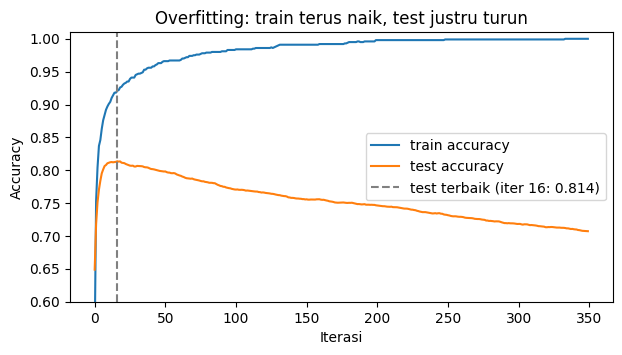

In [4]:
best = int(np.argmax(hist['test']))
plt.figure(figsize=(7, 3.5))
plt.plot(hist['train'], label='train accuracy')
plt.plot(hist['test'], label='test accuracy')
plt.axvline(best, color='gray', ls='--', label=f'test terbaik (iter {best}: {hist["test"][best]:.3f})')
plt.xlabel('Iterasi'); plt.ylabel('Accuracy'); plt.legend(); plt.ylim(0.6, 1.01)
plt.title('Overfitting: train terus naik, test justru turun')
plt.show()

## 3. Overfitting pada Neural Network

**Overfitting** terjadi ketika network makin bagus di training set tetapi makin buruk di test set. Analogi Trask: **cetakan garpu (fork mold)**. Jika cetakan dibuat dari 3 garpu tertentu dan dipakai terlalu lama, cetakan akan menangkap detail unik ketiga garpu itu (goresan, bengkok) sehingga garpu jenis lain tidak lagi muat.

### Dari mana asalnya?
Network belajar **detail** (noise) dan bukan hanya **sinyal**. Misalnya, di MNIST setiap angka punya pola piksel di tengah gambar (sinyal), tetapi juga variasi kecil acak di setiap gambar (noise). Bobot yang terus dilatih akhirnya menyesuaikan diri pada noise tersebut. Pada iterasi awal network menangkap sinyal besar; seiring waktu ia mulai menghafal detail.

## 4. Regularisasi Paling Sederhana: Early Stopping

**Regularization** = metode apa pun yang membuat model **menggeneralisasi** dengan baik, biasanya dengan mencegah model mempelajari detail halus.

**Early stopping**: berhenti training ketika performa di data validasi mulai menurun. Penting: jangan memakai **test set** untuk memilih kapan berhenti (itu namanya *peeking*); gunakan **validation set** terpisah dari training.

In [5]:
# Early stopping dengan validation set: 1000 gambar lain dari training set
val_images = x_train[1000:2000].reshape(1000, 784) / 255
val_labels = np.eye(10)[y_train[1000:2000]]

np.random.seed(1)
w01 = 0.2 * np.random.random((784, hidden_size)) - 0.1
w12 = 0.2 * np.random.random((hidden_size, 10)) - 0.1
best_val, best_w, patience, wait = 0, None, 20, 0

for j in range(iterations):
    for i in range(len(images)):
        l0 = images[i:i + 1]
        l1 = relu(l0.dot(w01)); l2 = l1.dot(w12)
        d2 = l2 - labels[i:i + 1]
        d1 = d2.dot(w12.T) * relu2deriv(l1)
        w12 -= alpha * l1.T.dot(d2); w01 -= alpha * l0.T.dot(d1)
    val_acc = evaluate(w01, w12, val_images, val_labels)[1]
    if val_acc > best_val:
        best_val, best_w, wait = val_acc, (w01.copy(), w12.copy()), 0
    else:
        wait += 1
        if wait >= patience:
            break

print(f'Berhenti di iterasi {j}, val-acc terbaik {best_val:.3f}')
print(f'Test-acc dengan bobot terbaik: {evaluate(*best_w, test_images, test_labels)[1]:.4f}')

Berhenti di iterasi 26, val-acc terbaik 0.815
Test-acc dengan bobot terbaik: 0.8012


## 5. Regularisasi Standar Industri: Dropout

**Dropout**: selama training, **matikan secara acak** sebagian neuron (set ke 0). Network dipaksa belajar memakai bagian-bagian yang berbeda setiap kali, sehingga tidak bisa bergantung pada kombinasi neuron tertentu untuk menghafal noise.

Analogi Trask: network besar seperti *pahatan* yang bisa menangkap detail halus; dropout membuatnya bertindak seperti banyak network kecil yang hanya bisa menangkap pola kasar (sinyal).

## 6. Mengapa Dropout Bekerja: Ensembling

Dropout adalah bentuk **ensembling**: setiap mask acak menghasilkan sub-network berbeda. Sub-network yang berbeda akan **overfit pada noise yang berbeda**, tetapi sepakat pada **sinyal** yang sama. Saat digabung (semua neuron aktif saat testing), noise saling membatalkan dan sinyal menguat.

> *"Neural networks, even though they're randomly generated, still start by learning the biggest, most broadly sweeping features before learning much about the noise."*

## 7. Dropout dalam Kode

```python
dropout_mask = np.random.randint(2, size=layer_1.shape)  # 50% neuron dimatikan
layer_1 *= dropout_mask * 2                              # *2 agar total sinyal tetap sama
...
layer_1_delta *= dropout_mask                            # neuron mati tidak di-update
```

Mengalikan dengan **2** penting: karena separuh neuron mati, sinyal ke `layer_2` akan setengahnya. Pengali 2 menjaga skala output sama dengan saat testing (tanpa dropout).

In [6]:
def train_mnist(iterations=300, alpha=0.005, hidden_size=100, dropout=False, batch_size=1, seed=1, log_every=50):
    np.random.seed(seed)
    w01 = 0.2 * np.random.random((784, hidden_size)) - 0.1
    w12 = 0.2 * np.random.random((hidden_size, 10)) - 0.1
    hist = {'train': [], 'test': []}
    for j in range(iterations):
        correct = 0
        for i in range(0, len(images), batch_size):
            l0 = images[i:i + batch_size]
            y = labels[i:i + batch_size]
            l1 = relu(l0.dot(w01))
            if dropout:
                mask = np.random.randint(2, size=l1.shape)
                l1 *= mask * 2
            l2 = l1.dot(w12)
            correct += (l2.argmax(1) == y.argmax(1)).sum()

            d2 = (l2 - y) / batch_size
            d1 = d2.dot(w12.T) * relu2deriv(l1)
            if dropout:
                d1 *= mask
            w12 -= alpha * l1.T.dot(d2)
            w01 -= alpha * l0.T.dot(d1)
        hist['train'].append(correct / len(images))
        hist['test'].append(evaluate(w01, w12, test_images, test_labels)[1])
        if log_every and (j % log_every == 0 or j == iterations - 1):
            print(f'I:{j:3d}  Train-Acc:{hist["train"][-1]:.3f}  Test-Acc:{hist["test"][-1]:.4f}')
    return hist

hist_dropout = train_mnist(iterations=300, hidden_size=100, dropout=True)

I:  0  Train-Acc:0.413  Test-Acc:0.6333


I: 50  Train-Acc:0.836  Test-Acc:0.8133


I:100  Train-Acc:0.864  Test-Acc:0.7903


I:150  Train-Acc:0.883  Test-Acc:0.8107


I:200  Train-Acc:0.893  Test-Acc:0.8036


I:250  Train-Acc:0.899  Test-Acc:0.8182


I:299  Train-Acc:0.916  Test-Acc:0.8229


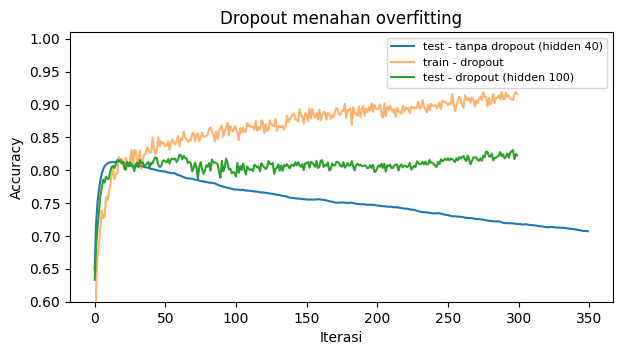

In [7]:
plt.figure(figsize=(7, 3.5))
plt.plot(hist['test'], label='test - tanpa dropout (hidden 40)')
plt.plot(hist_dropout['train'], label='train - dropout', alpha=0.6)
plt.plot(hist_dropout['test'], label='test - dropout (hidden 100)')
plt.xlabel('Iterasi'); plt.ylabel('Accuracy'); plt.legend(fontsize=8); plt.ylim(0.6, 1.01)
plt.title('Dropout menahan overfitting')
plt.show()

Dengan dropout, akurasi test **tidak lagi merosot** dan puncaknya lebih tinggi; akurasi train juga tidak lagi menempel di 100% — tanda network tidak sekadar menghafal.

## 8. Batch Gradient Descent

Alih-alih update per gambar, **mini-batch GD** memproses **n gambar sekaligus** (misal 100), merata-ratakan weight_delta-nya, lalu update sekali.

Keuntungan:
- **Lebih cepat** — perkalian matriks besar jauh lebih efisien daripada banyak perkalian vektor kecil.
- **Lebih stabil** — rata-rata weight_delta dari 100 contoh lebih sedikit noise-nya dibanding satu contoh, sehingga kita bisa memakai **alpha lebih besar**.

Perhatikan pembagian `/ batch_size` pada `d2` di fungsi di atas: itulah rata-rata weight_delta dalam satu batch.

In [8]:
import time

t0 = time.perf_counter()
hist_batch = train_mnist(iterations=300, alpha=0.1, hidden_size=100, dropout=True, batch_size=100)
print(f'Waktu: {time.perf_counter() - t0:.1f} detik')

I:  0  Train-Acc:0.161  Test-Acc:0.3832


I: 50  Train-Acc:0.784  Test-Acc:0.7978


I:100  Train-Acc:0.805  Test-Acc:0.8029


I:150  Train-Acc:0.818  Test-Acc:0.7967


I:200  Train-Acc:0.844  Test-Acc:0.8089


I:250  Train-Acc:0.851  Test-Acc:0.8074


I:299  Train-Acc:0.852  Test-Acc:0.8116
Waktu: 57.2 detik


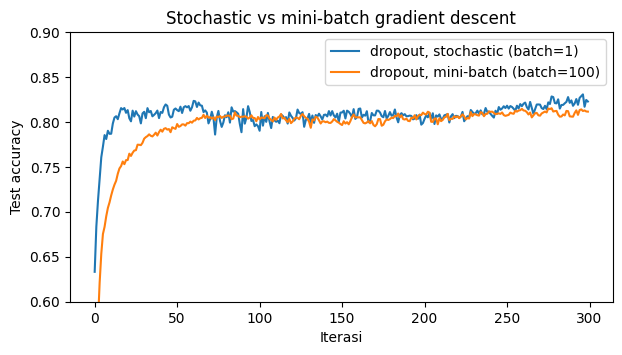

In [9]:
plt.figure(figsize=(7, 3.5))
plt.plot(hist_dropout['test'], label='dropout, stochastic (batch=1)')
plt.plot(hist_batch['test'], label='dropout, mini-batch (batch=100)')
plt.xlabel('Iterasi'); plt.ylabel('Test accuracy'); plt.legend(); plt.ylim(0.6, 0.9)
plt.title('Stochastic vs mini-batch gradient descent')
plt.show()

Mini-batch memberi kurva yang **lebih halus**, dan setiap iterasi jauh **lebih cepat** karena hanya ada 10 update matriks besar per epoch (bukan 1000 update kecil). Karena rata-rata weight_delta lebih stabil, kita bisa memakai alpha yang jauh lebih besar (0.1 vs 0.005).

## Rangkuman Bab 8

- Network 3 layer dengan mudah mencapai ~100% akurasi training di MNIST, tetapi akurasi test **turun** seiring waktu: **overfitting**.
- **Memorization ≠ generalization**; yang penting adalah performa pada data yang belum pernah dilihat.
- Overfitting terjadi karena network mempelajari **noise**, bukan hanya **sinyal**.
- **Early stopping**: hentikan training saat performa validation mulai turun (pakai validation set, bukan test set).
- **Dropout**: matikan neuron acak saat training (dan kalikan sisanya ×2) — bentuk **ensembling** yang menekan noise.
- **Mini-batch GD**: rata-ratakan weight_delta per batch → lebih cepat, lebih stabil, alpha bisa lebih besar.